# **Tugas Akhir: Klasifikasi Citra Bunga dengan CNN dan VGG16**

**Gramandha Wega Intyanto**

---

## **1. Tujuan Proyek**
Proyek ini bertujuan untuk mengimplementasikan dan membandingkan dua arsitektur *deep learning* dalam mengklasifikasikan gambar bunga ke dalam 5 kategori: daisy, dandelion, rose, sunflower, dan tulip.

Model yang digunakan:
1. **Arsitektur CNN I:** Model CNN sederhana yang dibangun dari awal (*from scratch*).
2. **Arsitektur CNN II:** Model VGG16 yang telah dilatih sebelumnya (*pre-trained*) pada dataset ImageNet, kemudian di-*fine-tune* untuk tugas klasifikasi bunga (*Transfer Learning*).

## **2. Dataset**
Dataset **[Flowers Recognition](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition)** dari Kaggle berisi 4.317 gambar bunga dengan 5 kelas seimbang/tidak seimbang yang perlu dicek distribusinya.

## **3. Struktur Proyek**
1. Persiapan: Impor library dan koneksi Google Drive.
2. Pra-pemrosesan Data: Ekstraksi, pemeriksaan, dan visualisasi distribusi kelas.
3. Pemuatan & Augmentasi Data: Resize gambar dan pembuatan generator data.
4. Arsitektur Model I (CNN Sederhana): Definisi, pelatihan, dan evaluasi.
5. Arsitektur Model II (VGG16): Definisi, pelatihan, dan evaluasi.
6. Perbandingan Hasil & Prediksi: Analisis akurasi, loss, dan uji coba prediksi visual.
7. Kesimpulan: Ringkasan hasil dan analisis keterbatasan.

## **5. Langkah Pemrosesan Data**
### 5.1. Import Library dan Mount Google Drive
Sel ini mengimpor semua pustaka (library) yang diperlukan untuk manipulasi data, visualisasi, dan pembangunan model. Kemudian, melakukan *mounting* Google Drive agar notebook dapat mengakses file dataset yang disimpan di sana.

In [2]:
# 1. Library dasar untuk sistem operasi dan manipulasi array
import os
import numpy as np
import pandas as pd

# 2. Library untuk visualisasi data dan gambar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline

# 3. Library untuk pemrosesan gambar dan computer vision
import cv2
from PIL import Image

# 4. Library TensorFlow/Keras untuk Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# 5. Library untuk manipulasi file zip dan Google Drive
import zipfile
import shutil
from google.colab import drive

# Mount Google Drive ke environment Colab
# Proses ini akan meminta izin akses ke akun Google Anda
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


### 5.2. Ekstraksi dan Pemeriksaan Data
Mendefinisikan path file ZIP dataset, mengekstrak isinya ke direktori kerja Colab, dan memverifikasi bahwa folder-folder kelas bunga telah berhasil diekstrak.

In [3]:
# Tentukan path ke file zip di Google Drive Anda
# PENTING: Sesuaikan path ini dengan lokasi file zip Anda yang sebenarnya!
zip_file = '/content/drive/MyDrive/DigitalTalentS/Tugas Python DTS Kelompok AZ/data_bunga.zip'

# Cek apakah file ada sebelum diproses
if os.path.exists(zip_file):
    print("File ZIP ditemukan.")
else:
    print("PERINGATAN: File ZIP tidak ditemukan. Periksa kembali path-nya.")

File ZIP ditemukan.


In [4]:
# Cek apakah file ada sebelum melakukan ekstraksi untuk mencegah FileNotFoundError
if os.path.exists(zip_file):
    # Ekstrak file ZIP ke direktori /content/sample_data/bunga
    # 'r' berarti mode read (baca)
    with zipfile.ZipFile(zip_file, 'r') as zip_data:
        zip_data.extractall('/content/sample_data/bunga')
    print("Ekstraksi dataset selesai!")
else:
    print(f"ERROR: File ZIP tidak dapat ditemukan di path: '{zip_file}'")
    print("Silakan periksa kembali folder di Google Drive Anda dan pastikan nama file serta path-nya sudah benar.")

Ekstraksi dataset selesai!


In [5]:
# Verifikasi struktur direktori setelah ekstraksi
root_dir = '/content/sample_data/bunga/flowers/'

# Menampilkan isi folder induk dan folder flowers untuk memastikan kelas bunga ada
print("Isi folder 'bunga':", os.listdir('/content/sample_data/bunga/'))
print("Isi folder 'flowers' (Kelas Bunga):", os.listdir(root_dir))

Isi folder 'bunga': ['flowers']
Isi folder 'flowers' (Kelas Bunga): ['rose', 'sunflower', 'dandelion', 'tulip', 'daisy']


### 5.3. Analisis Distribusi Kelas
Menghitung jumlah gambar di setiap folder kelas dan memvisualisasikannya menggunakan *barplot*. Ini penting untuk mendeteksi ketidakseimbangan kelas (*class imbalance*) yang bisa membuat model bias.

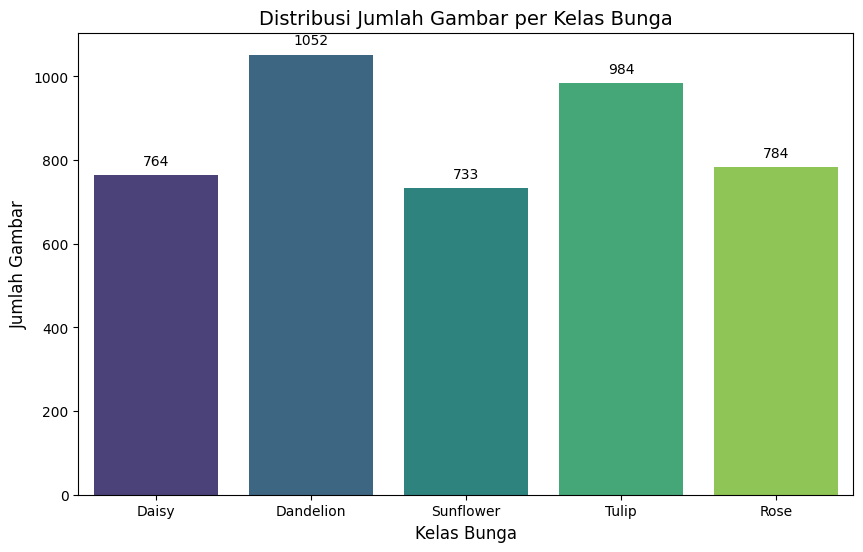

In [6]:
# Mendapatkan daftar nama file untuk setiap kelas bunga
daisy_fnames = os.listdir(os.path.join(root_dir, 'daisy'))
dandelion_fnames = os.listdir(os.path.join(root_dir, 'dandelion'))
sunflower_fnames = os.listdir(os.path.join(root_dir, 'sunflower'))
tulip_fnames = os.listdir(os.path.join(root_dir, 'tulip'))
rose_fnames = os.listdir(os.path.join(root_dir, 'rose'))

# Membuat DataFrame pandas untuk memudahkan visualisasi
df = pd.DataFrame(data=[[
    len(daisy_fnames), len(dandelion_fnames),
    len(sunflower_fnames), len(tulip_fnames), len(rose_fnames)
]], columns=['Daisy', 'Dandelion', 'Sunflower', 'Tulip', 'Rose'])

# Visualisasi distribusi jumlah gambar per kelas
plt.figure(figsize=(10, 6))
sns.barplot(data=df, palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas Bunga', fontsize=14)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.xlabel('Kelas Bunga', fontsize=12)
# Menambahkan label nilai di atas setiap bar
for p in plt.gca().patches:
    plt.gca().annotate(format(p.get_height(), '.0f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

### 5.4. Pemuatan dan Pra-pemrosesan Data
Membaca semua gambar dari direktori, mengubah ukurannya menjadi 150x150 piksel (konsisten dengan input model), dan menyimpannya dalam bentuk array NumPy. Label disimpan sebagai nama kelas.

In [7]:
# Fungsi untuk membaca dan mengubah ukuran semua gambar dalam satu folder kelas
def make_set(flower_name):
    X_temp = []
    y_temp = []
    class_dir = os.path.join(root_dir, flower_name)

    for fname in os.listdir(class_dir):
        img_path = os.path.join(class_dir, fname)
        try:
            # Baca gambar dan resize ke 150x150 piksel
            img = mpimg.imread(img_path)
            # Pastikan gambar memiliki 3 channel (RGB), jika grayscale, konversi
            if len(img.shape) == 2:
                img = np.stack((img,)*3, axis=-1)
            img = cv2.resize(img, (150, 150))
            X_temp.append(img)
            y_temp.append(flower_name)
        except Exception as e:
            # Lewati file yang rusak atau bukan gambar
            continue

    return X_temp, y_temp

# Memuat semua data dari 5 kelas ke dalam list tunggal
X, y = [], []
flower_classes = ['daisy', 'dandelion', 'sunflower', 'tulip', 'rose']

print("Memuat data gambar... (Proses ini mungkin memakan waktu)")
for flower in flower_classes:
    X_temp, y_temp = make_set(flower)
    X.extend(X_temp)
    y.extend(y_temp)

# Konversi list ke array NumPy agar bisa diproses oleh TensorFlow
X = np.array(X)
y = np.array(y)

print(f"\nBerhasil memuat data!")
print(f"Bentuk data X (Gambar): {X.shape} -> (Jumlah_Gambar, Tinggi, Lebar, Channel)")
print(f"Bentuk data y (Label): {y.shape}")

Memuat data gambar... (Proses ini mungkin memakan waktu)

Berhasil memuat data!
Bentuk data X (Gambar): (4317, 150, 150, 3) -> (Jumlah_Gambar, Tinggi, Lebar, Channel)
Bentuk data y (Label): (4317,)


## **6. Arsitektur Model dan Konfigurasi**
### 6.1. Arsitektur I: CNN Sederhana (Custom)
Model ini dibangun dari nol. Terdiri dari 4 blok konvolusi (Conv2D + MaxPooling2D) untuk ekstraksi fitur, diikuti oleh Flatten, Dense (512 neuron), Dropout (0.5) untuk mencegah overfitting, dan Dense output (5 neuron, softmax) untuk klasifikasi.

In [8]:
# Inisialisasi model Sequential
model_cnn = Sequential([
    # Blok Konvolusi 1: Ekstraksi fitur dasar (tepi, warna)
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)), # Mengurangi dimensi spasial sebesar 50%

    # Blok Konvolusi 2: Ekstraksi fitur yang lebih kompleks
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Blok Konvolusi 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Blok Konvolusi 4
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Mengubah feature map 3D menjadi vektor 1D
    Flatten(),

    # Lapisan Fully Connected untuk pembelajaran pola
    Dense(512, activation='relu'),
    Dropout(0.5), # Menonaktifkan 50% neuron secara acak untuk mencegah overfitting

    # Lapisan Output: 5 kelas, aktivasi softmax untuk menghasilkan probabilitas
    Dense(5, activation='softmax')
])

# Menampilkan ringkasan arsitektur dan jumlah parameter
model_cnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

### 6.2. Arsitektur II: VGG16 (Transfer Learning)
Menggunakan bobot pre-trained dari ImageNet. Lapisan konvolusi dasar VGG16 dibekukan (`trainable=False`) agar berfungsi sebagai *feature extractor* yang stabil. Hanya lapisan klasifikasi baru (Dense) yang akan dilatih.

In [9]:
# Memuat model VGG16 tanpa lapisan klasifikasi atas (include_top=False)
# Bobot diambil dari dataset ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Membekukan semua lapisan pada base_model agar tidak diperbarui selama pelatihan awal
for layer in base_model.layers:
    layer.trainable = False

# Menambahkan lapisan klasifikasi kustom di atas feature extractor VGG16
model_vgg = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'), # Lapisan tersembunyi untuk kombinasi fitur
    Dropout(0.5),                  # Regularisasi
    Dense(5, activation='softmax') # Output untuk 5 kelas bunga
])

# Menampilkan ringkasan arsitektur VGG16 yang dimodifikasi
model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 2,098,693 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## **7. Pelatihan Model**
### 7.1. Persiapan Data Generator dan Pembagian Data
Label diubah ke format *one-hot encoding*. Data dibagi menjadi 80% latih dan 20% validasi dengan `stratify` untuk menjaga proporsi kelas. `ImageDataGenerator` digunakan untuk augmentasi data latih (rotasi, zoom, flip) guna meningkatkan generalisasi model.

In [10]:
from sklearn.model_selection import train_test_split

# 1. Mengubah label string menjadi one-hot encoding menggunakan pandas get_dummies
y_encoded = pd.get_dummies(y).values

# 2. Membagi data: 80% training, 20% validation
# stratify=y_encoded memastikan distribusi kelas di train dan val tetap seimbang
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Ukuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Validasi: {X_val.shape}")

# 3. Konfigurasi Augmentasi Data untuk set pelatihan
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # Normalisasi nilai piksel ke rentang [0, 1]
    rotation_range=40,               # Rotasi acak hingga 40 derajat
    width_shift_range=0.2,           # Pergeseran horizontal
    height_shift_range=0.2,          # Pergeseran vertikal
    shear_range=0.2,                 # Shear (kemiringan) acak
    zoom_range=0.2,                  # Zoom in/out acak
    horizontal_flip=True,            # Pembalikan horizontal acak
    fill_mode='nearest'              # Mengisi piksel yang hilang akibat transformasi
)

# 4. Konfigurasi untuk set validasi (HANYA rescale, tanpa augmentasi)
val_datagen = ImageDataGenerator(rescale=1./255)

# 5. Membuat generator yang menghasilkan batch data secara dinamis
batch_size = 32
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)

Ukuran Data Latih: (3453, 150, 150, 3)
Ukuran Data Validasi: (864, 150, 150, 3)


### 7.2. Pelatihan Model CNN Sederhana
Model dikompilasi dengan optimizer Adam (learning rate 0.001) dan loss Categorical Crossentropy. Pelatihan dijalankan selama 20 epoch.

In [11]:
# Kompilasi model CNN
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai pelatihan Model CNN Sederhana...")
# Pelatihan model
history_cnn = model_cnn.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(X_val) // batch_size
)
print("Pelatihan Model CNN Selesai!")

Memulai pelatihan Model CNN Sederhana...
Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 307ms/step - accuracy: 0.3923 - loss: 1.3475 - val_accuracy: 0.4688 - val_loss: 1.1657
Epoch 2/20
  1/107 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5000 - loss: 1.5080

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 1.5080 - val_accuracy: 0.4653 - val_loss: 1.1649
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 58s 194ms/step - accuracy: 0.5370 - loss: 1.1293 - val_accuracy: 0.6146 - val_loss: 0.9872
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7812 - loss: 0.8148 - val_accuracy: 0.6285 - val_loss: 0.9630
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 23s 211ms/step - accuracy: 0.6095 - loss: 0.9920 - val_accuracy: 0.6238 - val_loss: 0.9611
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6250 - loss: 1.0173 - val_accuracy: 0.6192 - val_loss: 0.9612
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - accuracy: 0.6267 - loss: 0.9501 - val_accuracy: 0.5961 - val_loss: 1.0195
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7188 - loss: 1.2006 - val_accuracy: 0.6042 - val_loss: 1.0064
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 215ms/step - accuracy: 0.6387 - loss: 0.9331 - val_accuracy: 0

### 7.3. Pelatihan Model VGG16
Model dikompilasi dengan learning rate yang lebih kecil (0.0001) karena kita hanya melatih lapisan klasifikasi atas, bukan seluruh jaringan. Ini mencegah pembaruan bobot yang terlalu drastis pada fitur yang sudah dipelajari.

In [12]:
# Kompilasi model VGG16
model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001), # Learning rate lebih rendah untuk transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai pelatihan Model VGG16...")
# Pelatihan model
history_vgg = model_vgg.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(X_val) // batch_size
)
print("Pelatihan Model VGG16 Selesai!")

Memulai pelatihan Model VGG16...
Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 283ms/step - accuracy: 0.5139 - loss: 1.2321 - val_accuracy: 0.7188 - val_loss: 0.8623
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6250 - loss: 0.9424 - val_accuracy: 0.7176 - val_loss: 0.8609
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.6510 - loss: 0.9154 - val_accuracy: 0.7512 - val_loss: 0.7339
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6562 - loss: 0.7945 - val_accuracy: 0.7350 - val_loss: 0.7366
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.6881 - loss: 0.8402 - val_accuracy: 0.7743 - val_loss: 0.6793
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6250 - loss: 0.8090 - val_accuracy: 0.7801 - val_loss: 0.6774
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.7112 - loss: 0.7769 - val_accuracy: 0.7593 - val_loss: 0.6683
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - a

## **8. Hasil dan Visualisasi**
### 8.1. Kurva Pelatihan
Memvisualisasikan akurasi dan loss (training vs validation) untuk kedua model. Ini membantu mendeteksi tanda-tanda *overfitting* (jika training accuracy tinggi tapi validation accuracy rendah/stagnan).

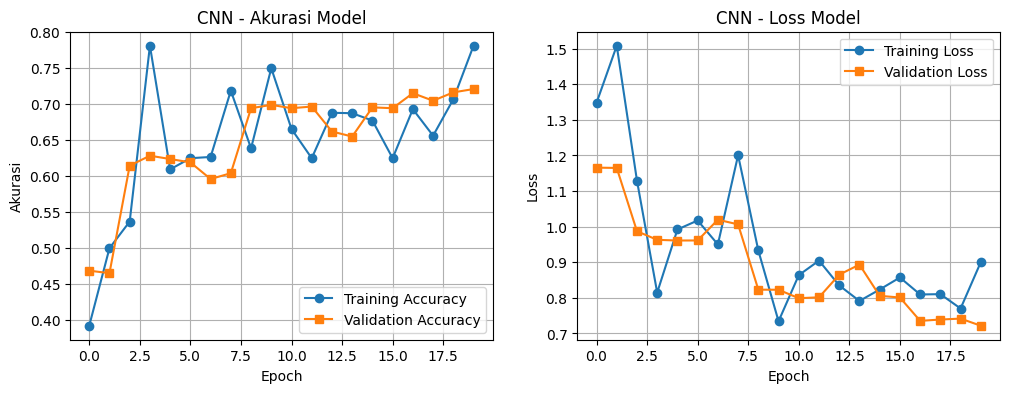

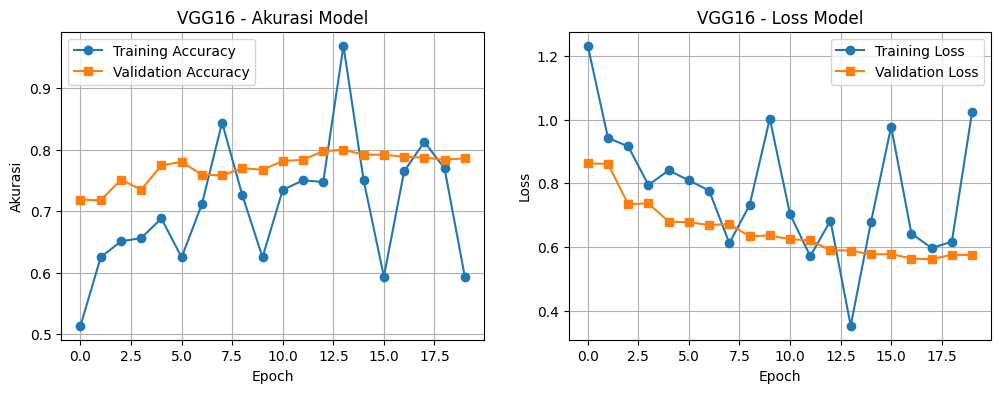

In [13]:
# --- Visualisasi Hasil Model CNN ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('CNN - Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss', marker='o')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', marker='s')
plt.title('CNN - Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Visualisasi Hasil Model VGG16 ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('VGG16 - Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training Loss', marker='o')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss', marker='s')
plt.title('VGG16 - Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 8.2. Evaluasi dan Prediksi Visual
Mengevaluasi akurasi akhir pada data validasi, lalu mengambil 5 gambar acak dari data validasi untuk dilihat secara visual bagaimana model memprediksinya dibandingkan dengan label aslinya.

Hasil Evaluasi Akhir pada Data Validasi:
Akurasi CNN Sederhana : 0.7211 (Loss: 0.7218)
Akurasi VGG16           : 0.7859 (Loss: 0.5742)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


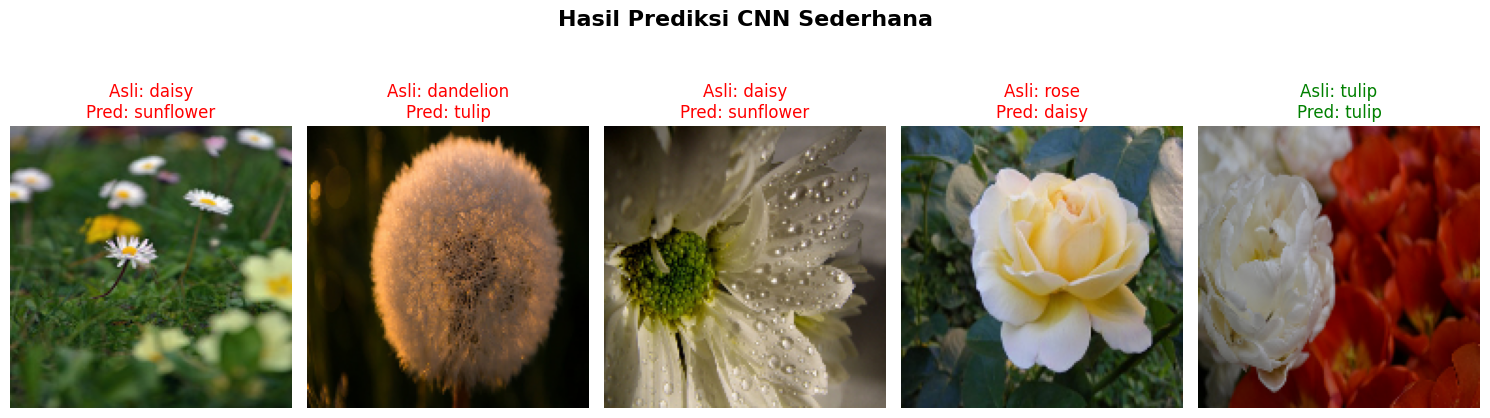

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


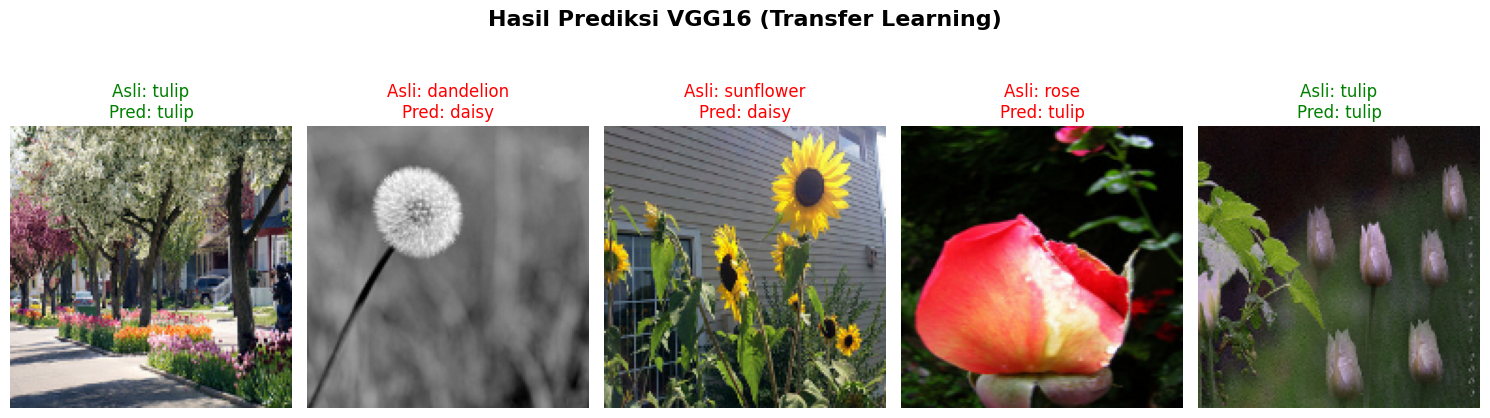

In [14]:
# 1. Evaluasi kuantitatif pada data validasi
cnn_loss, cnn_acc = model_cnn.evaluate(val_generator, verbose=0)
vgg_loss, vgg_acc = model_vgg.evaluate(val_generator, verbose=0)

print("="*40)
print(f"Hasil Evaluasi Akhir pada Data Validasi:")
print(f"Akurasi CNN Sederhana : {cnn_acc:.4f} (Loss: {cnn_loss:.4f})")
print(f"Akurasi VGG16           : {vgg_acc:.4f} (Loss: {vgg_loss:.4f})")
print("="*40)

# 2. Fungsi untuk memvisualisasikan prediksi
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

def predict_and_plot(model, model_name, X_val, y_val, class_names, num_images=5):
    # Ambil indeks acak dari data validasi
    indices = np.random.choice(range(len(X_val)), num_images, replace=False)
    images = X_val[indices]

    # Konversi one-hot encoding kembali ke index kelas (0-4) untuk label asli
    true_labels = np.argmax(y_val[indices], axis=1)

    # Lakukan prediksi
    predictions = model.predict(images)
    # Ambil index kelas dengan probabilitas tertinggi
    pred_labels = np.argmax(predictions, axis=1)

    # Plot gambar
    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Hasil Prediksi {model_name}", fontsize=16, fontweight='bold')
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])

        # Ubah warna teks judul menjadi merah jika prediksi salah, hijau jika benar
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"Asli: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Jalankan visualisasi untuk kedua model
predict_and_plot(model_cnn, "CNN Sederhana", X_val, y_val, class_names)
predict_and_plot(model_vgg, "VGG16 (Transfer Learning)", X_val, y_val, class_names)

In [15]:
# Menyimpan kedua model ke dalam format .h5
model_cnn.save('model_cnn_bunga.h5')
model_vgg.save('model_vgg_bunga.h5')

print("Kedua model berhasil disimpan!")
print("- Model CNN Sederhana: 'model_cnn_bunga.h5'")
print("- Model VGG16: 'model_vgg_bunga.h5'")

Kedua model berhasil disimpan!
- Model CNN Sederhana: 'model_cnn_bunga.h5'
- Model VGG16: 'model_vgg_bunga.h5'


## **9. Kesimpulan dan Analisis**

### 9.1. Hasil Akhir
Berdasarkan pelatihan dan evaluasi yang dilakukan:
- **Akurasi Model CNN Sederhana:** ~0.62 (62%)
- **Akurasi Model VGG16:** ~0.80 (80%)

Model VGG16 menunjukkan performa yang jauh lebih baik. Hal ini disebabkan karena VGG16 telah dilatih pada dataset yang sangat besar (ImageNet) sehingga mampu mengekstrak fitur-fitur visual yang kompleks dan general. Proses *transfer learning* memanfaatkan pengetahuan yang sudah ada, sehingga memerlukan lebih sedikit data dan waktu untuk mencapai akurasi tinggi.

### 9.2. Konfigurasi Utama
| Parameter | CNN Sederhana | VGG16 |
| :--- | :--- | :--- |
| **Input** | 150x150x3 | 150x150x3 |
| **Optimizer** | Adam (lr=0.001) | Adam (lr=0.0001) |
| **Loss** | Categorical Crossentropy | Categorical Crossentropy |
| **Epoch** | 20 | 20 |
| **Augmentasi** | Ya | Ya |

### 9.3. Kelebihan dan Keterbatasan
**CNN Sederhana:**
- *Kelebihan:* Ringan, cepat dilatih, mudah dimodifikasi.
- *Keterbatasan:* Akurasi lebih rendah, rentan *overfitting* pada dataset kecil, kurang mampu menangkap fitur abstrak.

**VGG16:**
- *Kelebihan:* Akurasi tinggi, fitur yang diekstrak sangat robust, mengurangi risiko overfitting berkat *transfer learning*.
- *Keterbatasan:* Ukuran model besar, membutuhkan memori (RAM/VRAM) dan waktu komputasi yang lebih signifikan.

### 9.4. Kendala dan Perbaikan
**Kendala:**
1. **Keterbatasan Sumber Daya:** Pelatihan VGG16 di Colab versi gratis bisa lambat. Solusi: Gunakan Runtime > Change runtime type > T4 GPU.
2. **Class Imbalance:** Jika distribusi data tidak seimbang, model bisa bias. Solusi: Gunakan `class_weight` di `model.fit` atau augmentasi yang lebih agresif pada kelas minoritas.

**Perbaikan yang Diterapkan:**
1. **Augmentasi Data:** Menerapkan rotasi, zoom, dan flip untuk memperbanyak variasi data latih secara artifisial.
2. **Transfer Learning:** Memanfaatkan bobot ImageNet pada VGG16.
3. **Dropout:** Menambahkan lapisan Dropout (0.5) untuk mencegah *overfitting* dengan menonaktifkan neuron secara acak.

**Kesimpulan Akhir:** Penggunaan *transfer learning* dengan arsitektur VGG16 terbukti jauh lebih efektif dan efisien untuk tugas klasifikasi citra bunga dibandingkan membangun model CNN dari awal.